In [ ]:
# FIX BUG DI SYMPY SU COLAB 
import sympy
import sympy.printing

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Ricerca dinamica della root del progetto
possible_roots = ["../", "./", "/content/neurovisiondl-unict-dlcmm-Maccarrone-Brancaforte-Cassia/"]
PROJECT_ROOT = None
for path in possible_roots:
    if os.path.exists(os.path.join(path, "src")):
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("⚠️ ERRORE: Root del progetto non trovata.")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.models import MLPBaseline, get_mobilenet_v2, get_resnet18, get_vit_b_16
from src.data_setup import create_dataloaders

sns.set_theme(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup completato. Device in uso: {device}")

✅ Setup completato. Device in uso: cuda


In [ ]:
DATA_DIR = os.path.join(PROJECT_ROOT, "data/raw/")

# Usiamo la tua funzione custom per caricare il Test Set a 4 classi
_, _, test_loader, original_classes = create_dataloaders(
    data_dir=DATA_DIR,
    phase='multiclass',
    batch_size=32
)

# Estraiamo i nomi delle classi in ordine di indice (0, 1, 2, 3)
# original_classes è del tipo: {'MildDemented': 0, 'ModerateDemented': 1, ...}
class_names = [k for k, v in sorted(original_classes.items(), key=lambda item: item[1])]

print(f"✅ Test Loader caricato con {len(test_loader.dataset)} immagini.")
print(f"Classi in ordine: {class_names}")

✅ Test Loader caricato con 5099 immagini.
Classi in ordine: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [ ]:
def evaluate_multiclass(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # Applichiamo Softmax per ottenere le probabilità tra 0 e 1 per le 4 classi
            probs = torch.softmax(outputs, dim=1)

            # La classe predetta è quella con la probabilità massima (Argmax)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

In [ ]:
MODELS_DIR = os.path.join(PROJECT_ROOT, "results/models/")

# Inizializziamo i modelli (pretrained=False perché caricheremo i NOSTRI pesi)
models_dict = {
    "MLP_Baseline": MLPBaseline(num_classes=4).to(device),
    "MobileNetV2": get_mobilenet_v2(num_classes=4, pretrained=False).to(device),
    "ResNet18": get_resnet18(num_classes=4, pretrained=False).to(device),
    "ViT_B_16": get_vit_b_16(num_classes=4, pretrained=False).to(device)
}

results_dict = {}

print("Inizio valutazione dei modelli (richiederà qualche minuto)...")
for name, model in models_dict.items():
    weights_path = os.path.join(MODELS_DIR, f"{name.lower()}_phase2.pth")

    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=False))
        print(f"Valutazione {name} in corso...")
        y_true, y_pred, y_probs = evaluate_multiclass(model, test_loader, device)
        results_dict[name] = {"y_true": y_true, "y_pred": y_pred, "y_probs": y_probs}
    else:
        print(f"⚠️ Attenzione: Pesi per {name} non trovati in {weights_path}.")

print("--> Valutazione completata!")

Inizio valutazione dei modelli (richiederà qualche minuto)...
Valutazione MLP_Baseline in corso...
Valutazione MobileNetV2 in corso...
Valutazione ResNet18 in corso...
Valutazione ViT_B_16 in corso...
✅ Valutazione completata!


In [ ]:
for name, data in results_dict.items():
    print(f"\n{'='*50}")
    print(f"📊 REPORT CLASSIFICAZIONE: {name}")
    print(f"{'='*50}")
    print(classification_report(data["y_true"], data["y_pred"], target_names=class_names, digits=3))


📊 REPORT CLASSIFICAZIONE: MLP_Baseline
                  precision    recall  f1-score   support

    MildDemented      0.511     0.766     0.613      1363
ModerateDemented      0.848     0.757     0.800       959
     NonDemented      0.674     0.524     0.590      1432
VeryMildDemented      0.419     0.339     0.375      1345

        accuracy                          0.584      5099
       macro avg      0.613     0.596     0.594      5099
    weighted avg      0.596     0.584     0.579      5099


📊 REPORT CLASSIFICAZIONE: MobileNetV2
                  precision    recall  f1-score   support

    MildDemented      0.993     0.999     0.996      1363
ModerateDemented      1.000     1.000     1.000       959
     NonDemented      0.989     0.985     0.987      1432
VeryMildDemented      0.984     0.983     0.984      1345

        accuracy                          0.991      5099
       macro avg      0.992     0.992     0.992      5099
    weighted avg      0.991     0.991     0.99

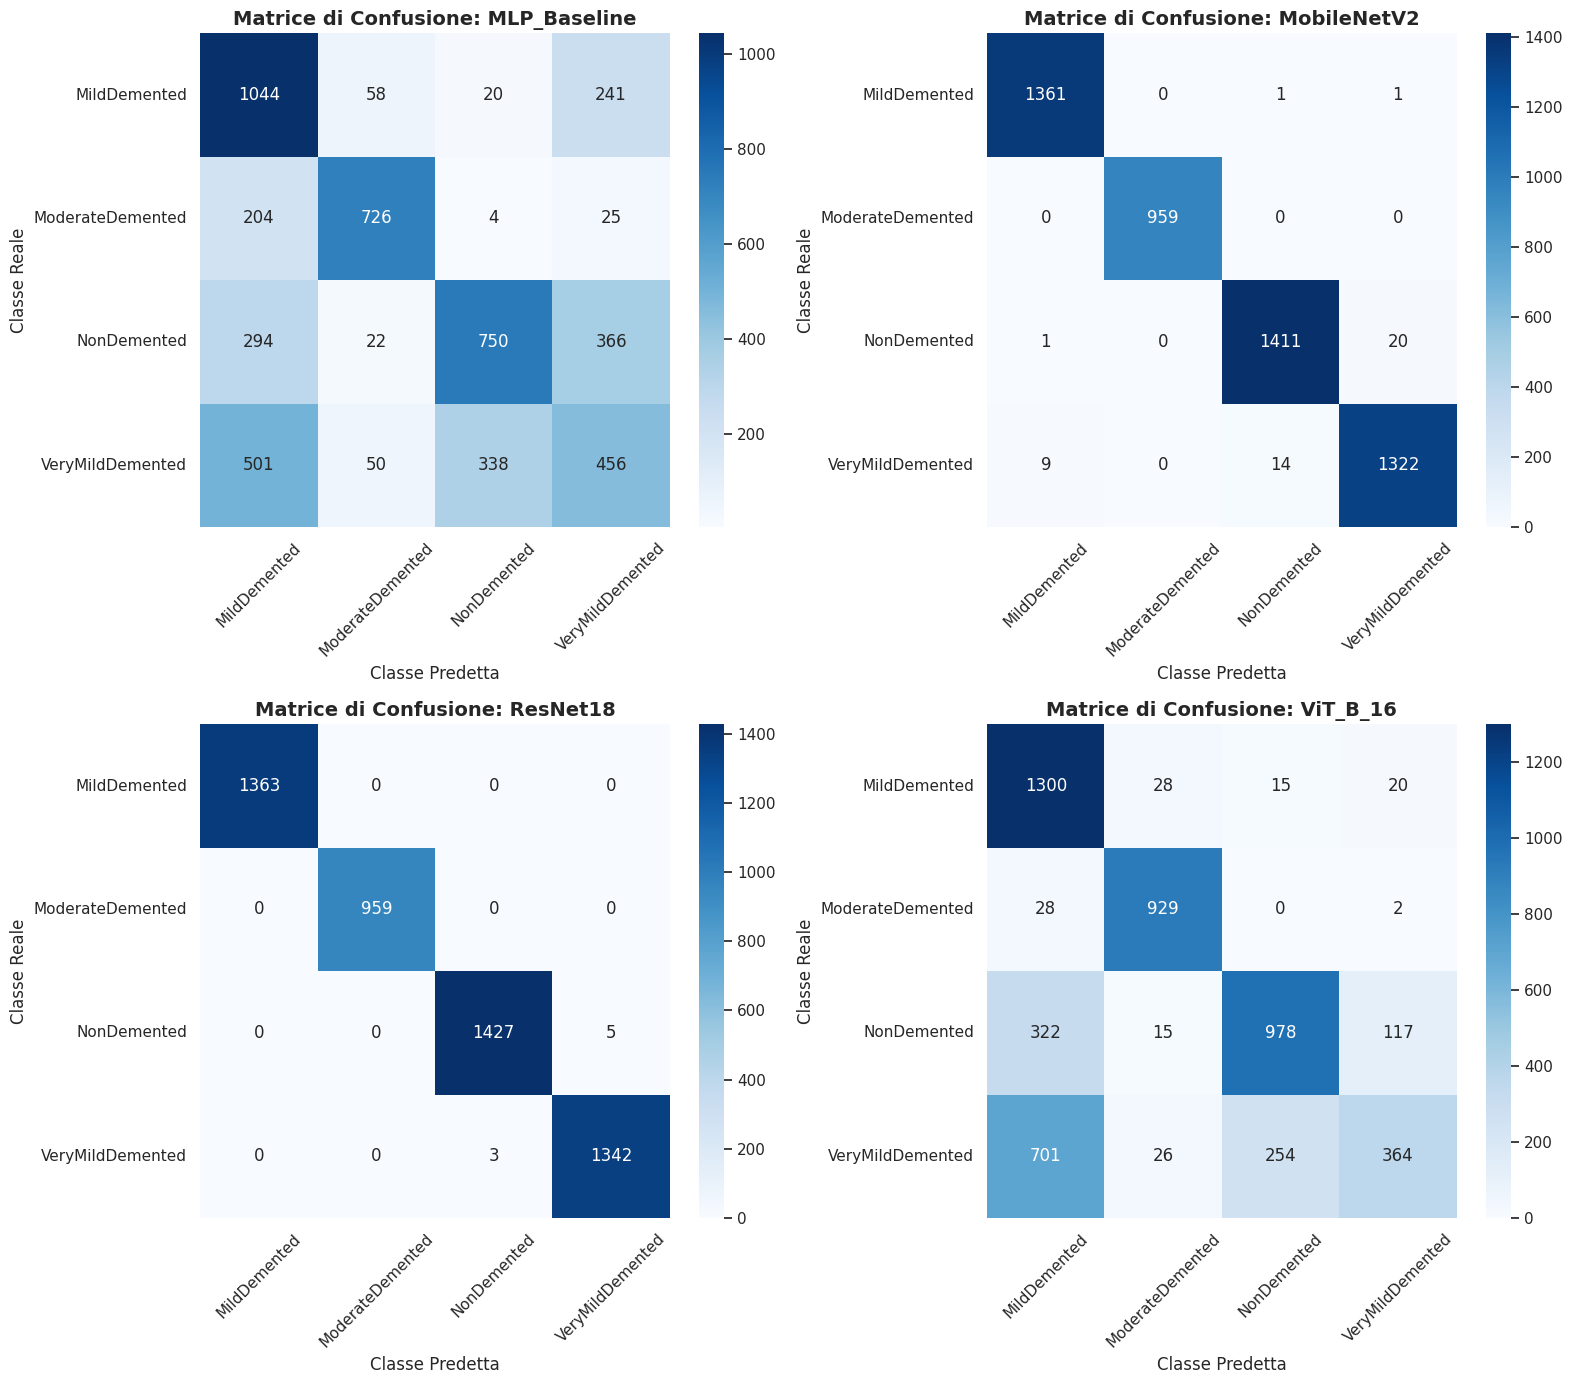

In [ ]:
# Impostiamo una griglia 2x2 per i grafici
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, data) in enumerate(results_dict.items()):
    cm = confusion_matrix(data["y_true"], data["y_pred"])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(f'Matrice di Confusione: {name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Classe Predetta')
    axes[idx].set_ylabel('Classe Reale')

    # Rota le etichette per una migliore leggibilità
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PROJECT_ROOT, "results/confusion_matrices_phase2.png"))

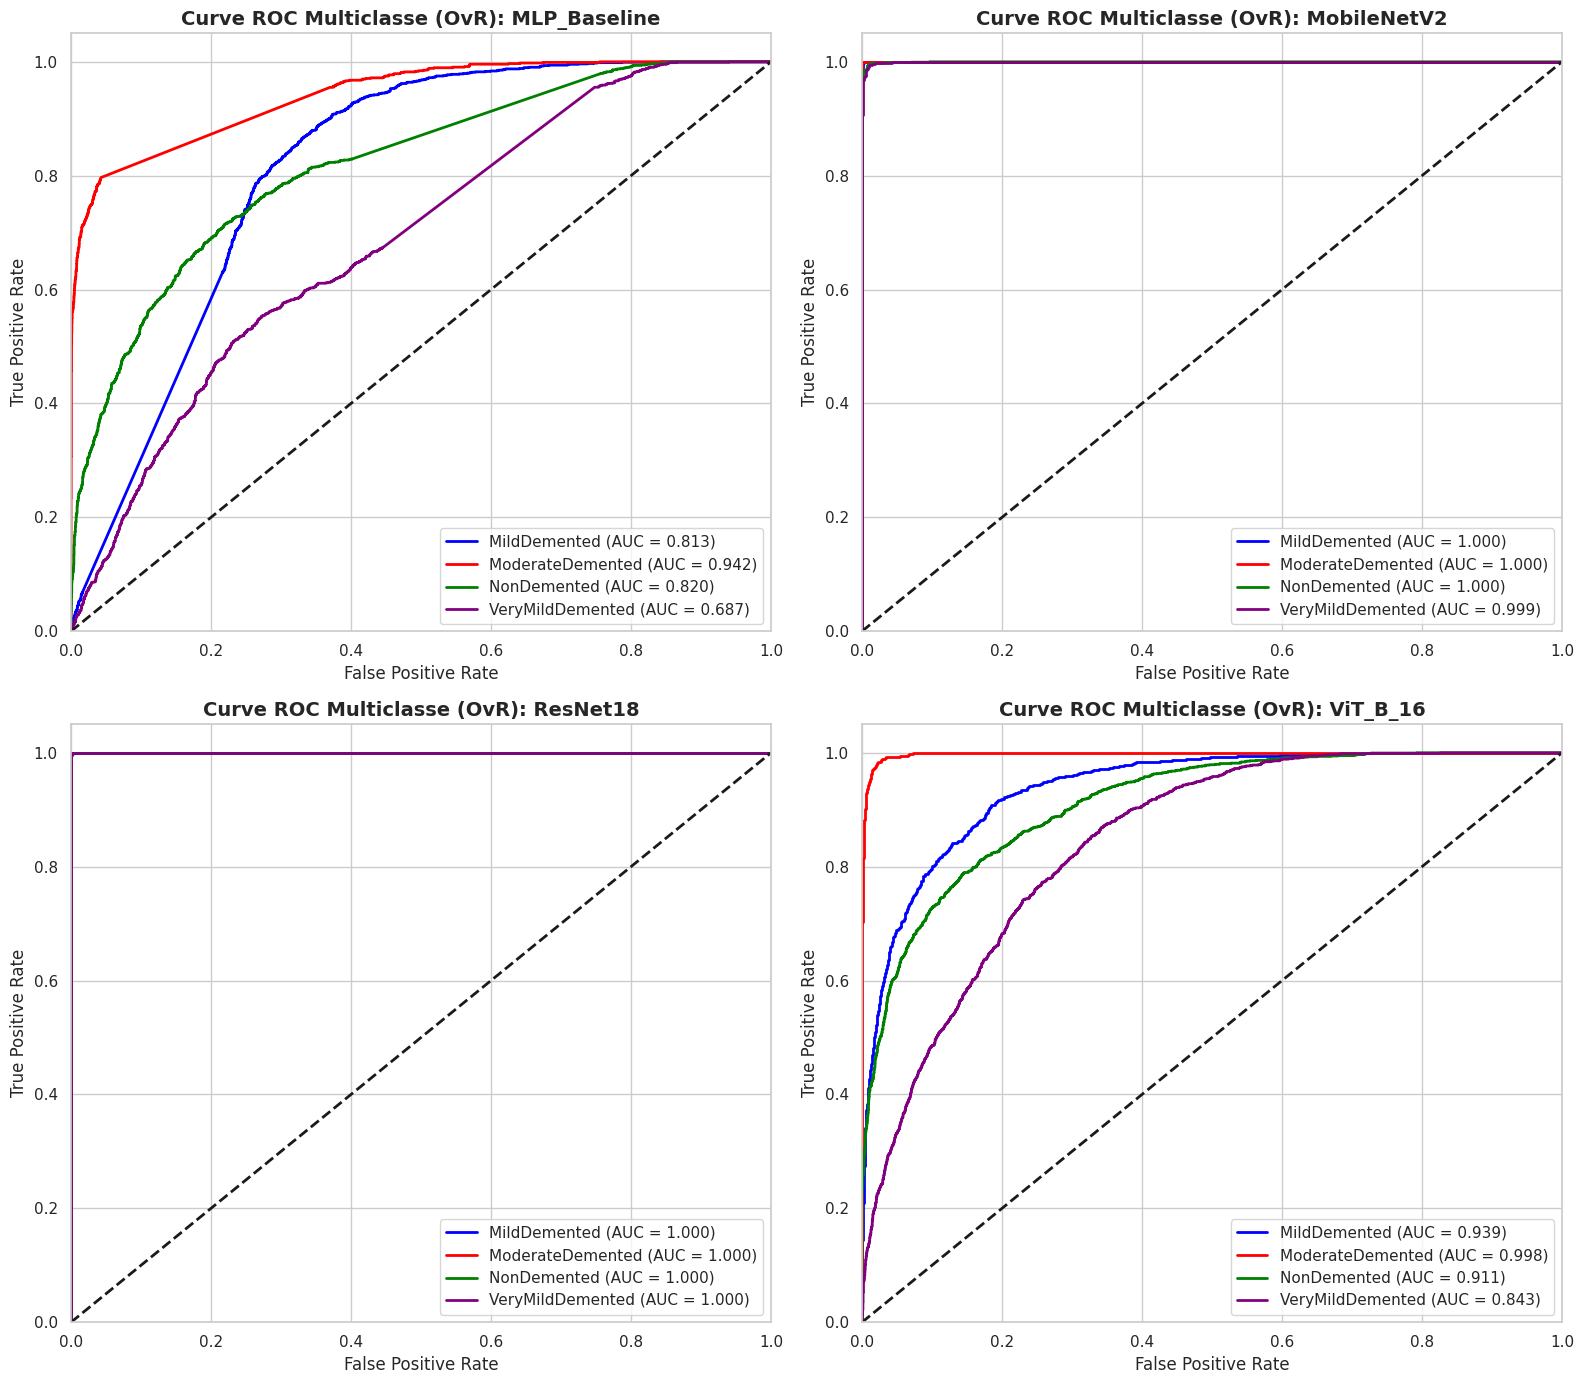

In [ ]:
n_classes = len(class_names)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Colori per le 4 linee
colors = ['blue', 'red', 'green', 'purple']

for idx, (name, data) in enumerate(results_dict.items()):
    y_true_bin = label_binarize(data["y_true"], classes=[0, 1, 2, 3])
    y_probs = data["y_probs"]

    ax = axes[idx]

    # Calcola e plotta la curva per ogni singola classe
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2) # Linea diagonale del caso casuale
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curve ROC Multiclasse (OvR): {name}', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PROJECT_ROOT, "results/roc_curves_phase2.png"))